# Sandbox - Likelihood

This notebook is used to prototype the likelihood function, used to generate all scenarios of use of the algorithm.

---

## Imports & Config

In [1]:
! pwd

/Users/simonlejoly/Documents/Work/mimosa/tests/identifiability


In [2]:
! export XLA_PYTHON_CLIENT_MEM_FRACTION=.25

In [3]:
# Jax configuration
USE_JIT = True
USE_X64 = True
DEBUG_NANS = False
VERBOSE = False

In [4]:
# Standard library imports
import os
os.environ['JAX_ENABLE_X64'] = str(USE_X64).lower()

import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [5]:
# Third party
import jax
jax.config.update("jax_disable_jit", not USE_JIT)
jax.config.update("jax_debug_nans", DEBUG_NANS)
import jax.random as jr
import jax.numpy as jnp
from jax import vmap, jit, Array, grad

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

import numpy as np

from kernax import ZeroMean, ConstantMean, LinearMean, AffineMean
from kernax import SEKernel, VarianceKernel, sample_hps_from_normal_priors, BatchModule, config
#config.parameter_transform = "exp"

In [6]:
# Local imports
from mimosa.sampling import sample_gp
from likelihood_comps import *

INFO:2026-03-06 22:47:50,376:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/mimosa/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
2026-03-06 22:47:50,376 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/miniconda3/envs/mimosa/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


In [7]:
key = jr.PRNGKey(42)

---

## GP identifiability - SE without noise

In [8]:
sample_jitter = jnp.array(1e-10)
nll_jitter = jnp.array(1e-3)

In [9]:
grid_range = (-3, 3)
nb_points = 200
grid = jnp.linspace(*grid_range, nb_points)[:, None]

In [10]:
kern_priors = {"variance":(2.5, .75), "length_scale": (1.5, .5)}
mean_priors = {"constant": (0., 2.5)}

### 1 sample

In [11]:
kern = VarianceKernel(variance=1.) * SEKernel(length_scale=1.)
key, subkey1, subkey2 = jr.split(key, 3)
kern = sample_hps_from_normal_priors(subkey1, kern, kern_priors)
mean = ConstantMean(constant=0.)
mean = sample_hps_from_normal_priors(subkey2, mean, mean_priors)
print(f"{kern}\n{mean}")

VarianceKernel(variance=2.59) * SEKernel(length_scale=1.40)
ConstantMean(constant=3.08)


In [12]:
key, subkey = jax.random.split(key)
vals = sample_gp(subkey, mean(grid), kern(grid), jitter=sample_jitter)
np.asarray(vals)

array([3.7351304 , 3.74116982, 3.74893342, 3.7583313 , 3.76937343,
       3.7820598 , 3.79628206, 3.81205976, 3.82929854, 3.84797764,
       3.86802396, 3.88938122, 3.91200888, 3.93585244, 3.96079708,
       3.98685222, 4.01391798, 4.04189048, 4.07075811, 4.10039559,
       4.13075136, 4.1617633 , 4.1933135 , 4.22537938, 4.257834  ,
       4.29061554, 4.32362889, 4.35680666, 4.39005988, 4.42331942,
       4.45643902, 4.48943301, 4.52214415, 4.55453422, 4.586472  ,
       4.61788411, 4.6487134 , 4.67887885, 4.70827844, 4.73682231,
       4.76444413, 4.79105921, 4.81658151, 4.84092697, 4.86402874,
       4.88581132, 4.90623145, 4.92517863, 4.9425888 , 4.95838961,
       4.972533  , 4.98494031, 4.99557693, 5.00434229, 5.01122785,
       5.01618619, 5.01912389, 5.01999935, 5.01886092, 5.0156026 ,
       5.01018543, 5.00262804, 4.99283556, 4.980875  , 4.96671927,
       4.95033297, 4.93170537, 4.91090227, 4.88788057, 4.86266715,
       4.83529618, 4.80577049, 4.77421367, 4.74050199, 4.70483

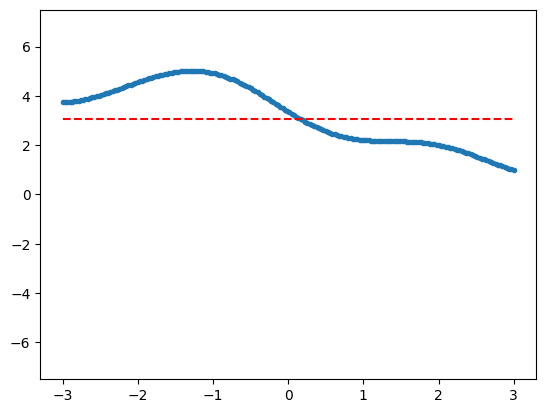

In [13]:
# Plot the sample
plt.scatter(grid, vals, marker=".")
plt.plot(grid, mean(grid), color='red', linestyle="--", label='True mean')
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-7.5, 7.5)
plt.show()

In [14]:
emp_var = jnp.mean((vals - mean(grid))**2)  # Variance around true mean
emp_var

Array(1.6114498, dtype=float64)

In [15]:
jnp.var(vals)  # Variance around empirical mean

Array(1.58165314, dtype=float64)

In [16]:
csts = jnp.linspace(mean_priors["constant"][0]-2*mean_priors["constant"][1], mean_priors["constant"][0]+2*mean_priors["constant"][1], 50)
vrs = jnp.exp(jnp.linspace(jnp.log(0.25), jnp.log(7.0), 100))

In [17]:
llh_from_hps = jit(lambda c, v:
                   mvn_nll(
	                   grid,
	                   vals[:, None],
	                   ConstantMean(constant=c)(grid)[None, :],
	                   (VarianceKernel(variance=v) * kern.right)(grid)[None, :, :],
	                   jitter=nll_jitter).squeeze())

In [18]:
llh_values = vmap(vmap(llh_from_hps, in_axes=(0, None)), in_axes=(None, 0))(csts, vrs)
llh_grads =  vmap(vmap(grad(llh_from_hps, argnums=(0, 1)), in_axes=(0, None)), in_axes=(None, 0))(csts, vrs)
llh_values.shape, llh_grads[0].shape,  llh_grads[1].shape

((100, 50), (100, 50), (100, 50))

In [19]:
orig_const = mean.constant.item()
orig_var = kern.left.variance.item()
var_opt, const_opt = jnp.unravel_index(jnp.argmin(llh_values), llh_values.shape)

In [20]:
orig_const, csts[const_opt].item(), orig_var, vrs[var_opt].item()

(3.076449244530506, 2.959183673469387, 2.5918918576972483, 2.3052181460292234)

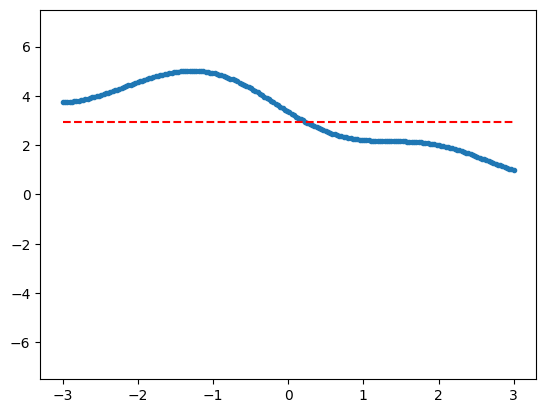

In [21]:
# Plot the sample
plt.scatter(grid, vals, marker=".")
plt.plot(grid, ConstantMean(constant=csts[const_opt])(grid), color='red', linestyle="--", label='True mean')
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-7.5, 7.5)
plt.show()

In [22]:
llh_values[var_opt, const_opt]

Array(-465.52741069, dtype=float64)

In [23]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['LLH values', 'variance grads', 'constant grads'],
    specs=[[{'type': 'surface'}, {'type': 'surface'}, {'type': 'surface'}],],
    horizontal_spacing=0.05,
    vertical_spacing=0.1,
)

# --- VALUES ---

fig.add_trace(go.Surface(x=csts, y=vrs, z=np.asarray(llh_values), showscale=False, colorscale='Viridis'), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=[orig_const], y=[orig_var], z=[llh_from_hps(orig_const, orig_var)],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=1)

fig.add_trace(go.Scatter3d(
    x=[csts[const_opt].item()], y=[vrs[var_opt].item()], z=[llh_values[var_opt, const_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Optimal HPs (constant={csts[const_opt].item():.2f}, variance={vrs[var_opt].item():.2f})',
    showlegend=False,
), row=1, col=1)

# --- GRADS (slope) ---

fig.add_trace(go.Surface(x=csts, y=vrs, z=np.asarray(llh_grads[1]), showscale=False, colorscale='Viridis'), row=1, col=2)

fig.add_trace(go.Surface(x=csts, y=vrs, z=np.asarray(jnp.zeros_like(llh_grads[1])), showscale=False, colorscale='Viridis'), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=[orig_const], y=[orig_var], z=[grad(llh_from_hps, argnums=(0, 1))(orig_const, orig_var)[1]],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=2)

fig.add_trace(go.Scatter3d(
    x=[csts[const_opt].item()], y=[vrs[var_opt].item()], z=[llh_grads[1][var_opt, const_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
    name=f'Optimal HPs (constant={csts[const_opt].item():.2f}, variance={vrs[var_opt].item():.2f})',
    showlegend=False,
), row=1, col=2)

# --- GRADS (intercept) ---

fig.add_trace(go.Surface(x=csts, y=vrs, z=np.asarray(llh_grads[0]), showscale=False, colorscale='Viridis'), row=1, col=3)

fig.add_trace(go.Surface(x=csts, y=vrs, z=np.asarray(jnp.zeros_like(llh_grads[0])), showscale=False, colorscale='Viridis'), row=1, col=3)

fig.add_trace(go.Scatter3d(
    x=[orig_const], y=[orig_var], z=[grad(llh_from_hps, argnums=(0, 1))(orig_const, orig_var)[0]],
    mode='markers', marker=dict(size=6, color='red'),
    showlegend=False,
), row=1, col=3)

fig.add_trace(go.Scatter3d(
    x=[csts[const_opt].item()], y=[vrs[var_opt].item()], z=[llh_grads[0][var_opt, const_opt].item()],
    mode='markers', marker=dict(size=6, color='green'),
	name=f'Optimal HPs (constant={csts[const_opt].item():.2f}, variance={vrs[var_opt].item():.2f})',
    showlegend=False,
), row=1, col=3)

fig.update_layout(
    title='NLL values and grads',
    scene =dict(xaxis_title='constant', yaxis_title='variance', zaxis_title='NLL values', xaxis_autorange='reversed', yaxis_autorange='reversed'),
    scene2=dict(xaxis_title='constant', yaxis_title='variance', zaxis_title='NLL grads - variance', xaxis_autorange='reversed', yaxis_autorange='reversed'),
    scene3=dict(xaxis_title='constant', yaxis_title='variance', zaxis_title='NLL grads - constant', xaxis_autorange='reversed', yaxis_autorange='reversed'),
	height=700
)

fig.show()

### Multi-sample

In [24]:
nb_samples = 1000
key, subkey_1, subkey_2, subkey_3 = jr.split(key, 4)

In [25]:
kern = VarianceKernel(variance=1.) * SEKernel(length_scale=1.)
kern = BatchModule(kern, batch_size=nb_samples, batch_in_axes=0, batch_over_inputs=False)  # Distinct HPs in each kernel
kern = sample_hps_from_normal_priors(subkey_1, kern, kern_priors)

# Ensure positivity of variance and length-scales
kern = kern.replace(inner=kern.inner.replace(left=kern.inner.left.replace(variance=jnp.abs(kern.inner.left.variance))))
kern = kern.replace(inner=kern.inner.replace(right=kern.inner.right.replace(length_scale=jnp.abs(kern.inner.right.length_scale))))

mean = ConstantMean(constant=0.)
mean = BatchModule(mean, batch_size=nb_samples, batch_in_axes=0, batch_over_inputs=False)
mean = sample_hps_from_normal_priors(subkey_2, mean, mean_priors)
print(f"{kern}\n{mean}")

VarianceKernel(variance=[2.52 ± 0.76]₁₀₀₀) * SEKernel(length_scale=[1.49 ± 0.50]₁₀₀₀)
ConstantMean(constant=[0.06 ± 2.51]₁₀₀₀)


In [26]:
subkeys = jr.split(subkey_3, nb_samples)
samples = vmap(lambda k, mu, cov: sample_gp(k, mu, cov, jitter=sample_jitter))(subkeys, mean(grid), kern(grid))
samples.shape

(1000, 200)

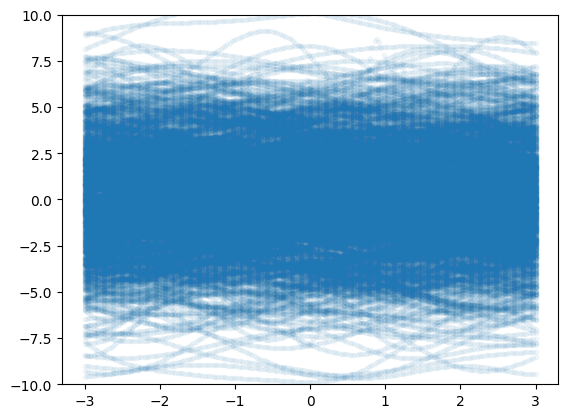

In [27]:
# Plot the sample
plt.scatter(jnp.broadcast_to(grid.T, samples.shape), samples, marker=".", alpha=0.05)
plt.xlim(*map(lambda x: x*1.1, grid_range))
plt.ylim(-10, 10)
plt.show()

In [28]:
llh_from_hps = jit(lambda smp, c, v, ls: mvn_nll(
    grid, smp[:, None],
    ConstantMean(constant=c)(grid)[None, :],
    (VarianceKernel(variance=v) * SEKernel(length_scale=ls))(grid)[None, :, :],
    jitter=nll_jitter).squeeze())

In [29]:
orig_lss = kern.inner.right.length_scale  # (nb_samples,) - length_scale fixed per sample
llh_values = jit(vmap(
    lambda smp, ls: vmap(vmap(llh_from_hps, in_axes=(None, 0, None, None)), in_axes=(None, None, 0, None))(smp, csts, vrs, ls)
))(samples, orig_lss)
llh_values.shape

(1000, 100, 50)

In [30]:
var_opt, const_opt = vmap(lambda lvs: jnp.unravel_index(jnp.argmin(lvs), lvs.shape))(llh_values)
var_opt.shape, const_opt.shape

((1000,), (1000,))

In [31]:
opti_csts = csts[const_opt]
orig_csts = mean.inner.constant
opti_vars = vrs[var_opt]
orig_vars = kern.inner.left.variance
opti_csts.shape, orig_csts.shape, opti_vars.shape, orig_vars.shape

((1000,), (1000,), (1000,), (1000,))

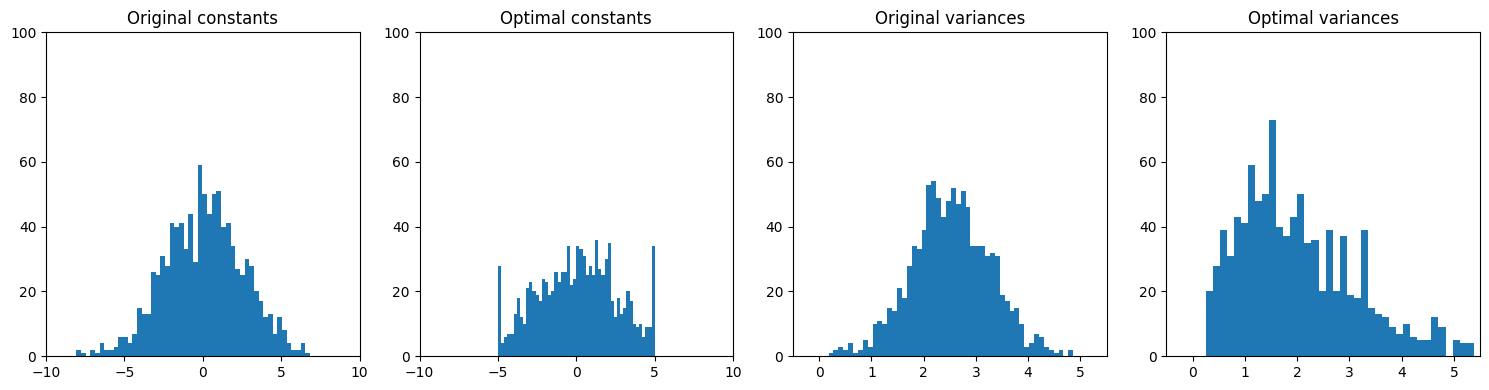

In [32]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))

ax[0].hist(orig_csts, bins=50)
ax[0].set_title("Original constants")
ax[0].set_xlim(mean_priors["constant"][0]-4*mean_priors["constant"][1], mean_priors["constant"][0]+4*mean_priors["constant"][1])
ax[0].set_ylim(0, 100)

ax[1].hist(opti_csts, bins=50)
ax[1].set_title("Optimal constants")
ax[1].set_xlim(mean_priors["constant"][0]-4*mean_priors["constant"][1], mean_priors["constant"][0]+4*mean_priors["constant"][1])
ax[1].set_ylim(0, 100)

ax[2].hist(orig_vars, bins=50)
ax[2].set_title("Original variances")
ax[2].set_xlim(kern_priors["variance"][0]-4*kern_priors["variance"][1], kern_priors["variance"][0]+4*kern_priors["variance"][1])
ax[2].set_ylim(0, 100)

ax[3].hist(opti_vars, bins=50)
ax[3].set_title("Optimal variances")
ax[3].set_xlim(kern_priors["variance"][0]-4*kern_priors["variance"][1], kern_priors["variance"][0]+4*kern_priors["variance"][1])
ax[3].set_ylim(0, 100)

plt.tight_layout()
plt.show()

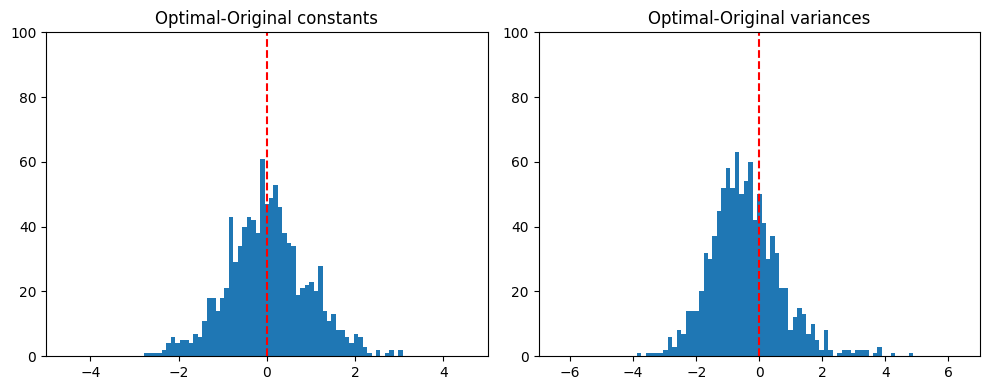

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

nb_bins = 100
cst_low, cst_high = -5., 5.
vr_low, vr_high = -7., 7.
cst_bins = jnp.linspace(cst_low, cst_high, nb_bins)
var_bins = jnp.linspace(vr_low, vr_high, nb_bins)

ax[0].hist(opti_csts - orig_csts, bins=cst_bins)
ax[0].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[0].set_title("Optimal-Original constants")
ax[0].set_xlim(cst_low, cst_high)
ax[0].set_ylim(0, 100)

ax[1].hist(opti_vars - orig_vars, bins=var_bins)
ax[1].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[1].set_title("Optimal-Original variances")
ax[1].set_xlim(vr_low, vr_high)
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

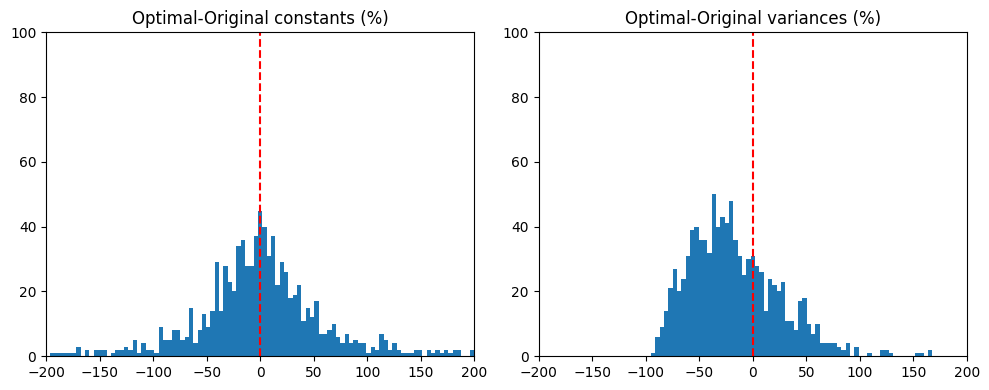

In [34]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

low, high = -200, 200
bins = jnp.linspace(low, high, 100)

ax[0].hist((opti_csts - orig_csts)/jnp.abs(orig_csts)*100, bins=bins)
ax[0].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[0].set_title("Optimal-Original constants (%)")
ax[0].set_xlim(low, high)
ax[0].set_ylim(0, 100)

ax[1].hist((opti_vars - orig_vars)/jnp.abs(orig_vars)*100, bins=bins)
ax[1].axvline(0, color='red', linestyle='--', label='Ground truth')
ax[1].set_title("Optimal-Original variances (%)")
ax[1].set_xlim(low, high)
ax[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

---